In [1]:
import json
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style = "darkgrid", palette = "muted")
plt.rcParams.update({"figure.dpi":120,"figure.figsize":(12,5)})

df = pd.read_parquet("/kaggle/input/notebooks/anymansince2005/schema-extraction/arxiv_ml_clean.parquet")
print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
df.head(2)

Dataset shape : (110, 8)
Columns       : ['paper_id', 'title', 'abstract', 'authors', 'categories', 'date', 'journal_ref', 'doi']


,paper_id,title,abstract,authors,categories,date,journal_ref,doi
0,0704.0047,Intelligent location of simultaneously active ...,The intelligent acoustic emission locator is...,[T. Kosel and I. Grabec],"[cs.NE, cs.AI]",2007-04-01 13:06:50,None,None
1,0704.0050,Intelligent location of simultaneously active ...,Part I describes an intelligent acoustic emi...,[T. Kosel and I. Grabec],"[cs.NE, cs.AI]",2007-04-01 18:53:13,None,None


In [2]:
print("\n"+"="*60)
print("BASIC STATS")
print("="*60)

print(f"\nTotal Papers      : {len(df):,}")
print(f"Date Range          : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Unique Authors      : {df['authors'].explode().nunique():,}")
print(f"Papers with DOI     : {df['doi'].notna().sum():,} ({df['doi'].notna().mean()*100:.1f}%)")
print(f"Papers with Journal : {df['journal_ref'].notna().sum():,} ({df['journal_ref'].notna().mean()*100:.1f}%)")
print(f"Null Abstracts      : {df['abstract'].isna().sum()}")

print("\nNull counts per column:")
print(df.isna().sum())


BASIC STATS

Total Papers      : 110
Date Range          : 2007-04-01 -> 2007-06-09
Unique Authors      : 194
Papers with DOI     : 17 (15.5%)
Papers with Journal : 31 (28.2%)
Null Abstracts      : 0

Null counts per column:
paper_id        0
title           0
abstract        0
authors         0
categories      0
date            0
journal_ref    79
doi            93
dtype: int64



Category Distribution

Papers per ML Category:
categories
Artificial Intelligence    60
Neural & Evolutionary      26
Computer Vision            17
Machine Learning           16
Computation & Language      9
Stats ML                    7


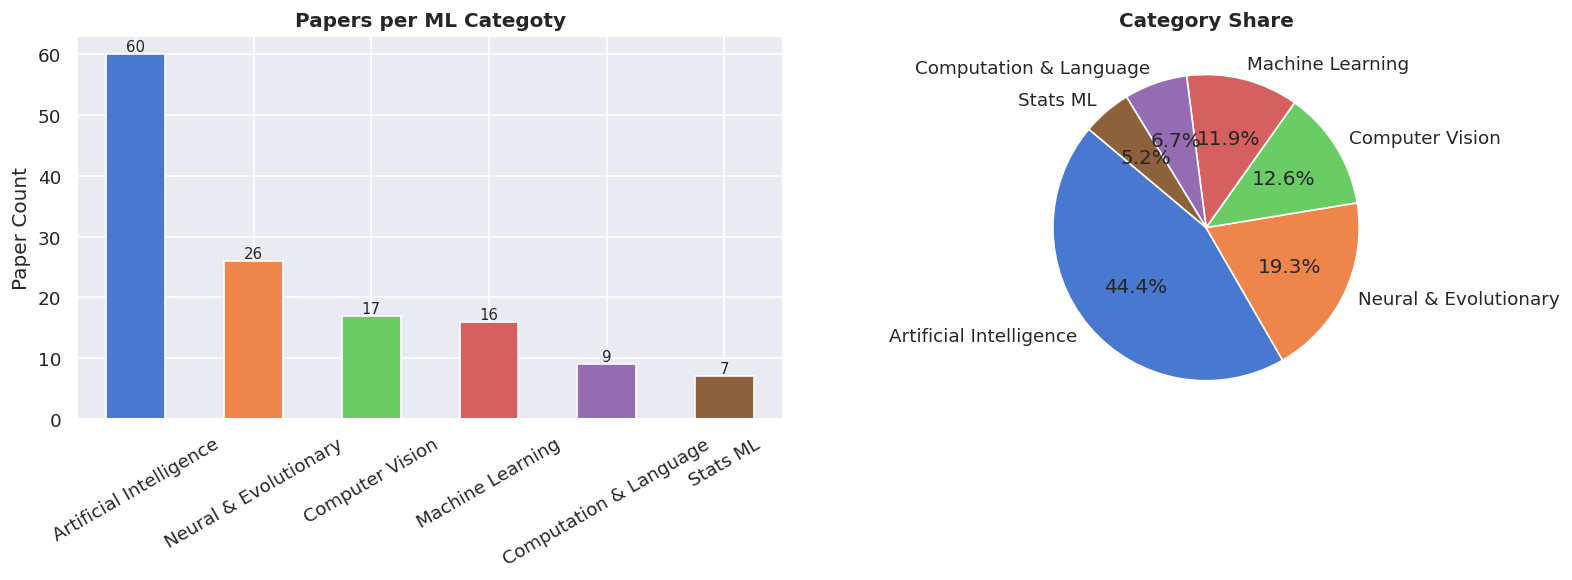

In [3]:
print("\n"+"="*60)
print("Category Distribution")
print("="*60)

cat_series = df['categories'].explode()
ML_CATEGORIES = {
    "cs.LG"   : "Machine Learning",
    "cs.AI"   : "Artificial Intelligence",
    "stat.ML" : "Stats ML",
    "cs.CL"   : "Computation & Language",
    "cs.CV"   : "Computer Vision",
    "cs.NE"   : "Neural & Evolutionary",
}

cat_counts = (
    cat_series[cat_series.isin(ML_CATEGORIES.keys())]
    .value_counts()
    .rename(index=ML_CATEGORIES)
)

print("\nPapers per ML Category:")
print(cat_counts.to_string())

#plot
fig,axes = plt.subplots(1,2, figsize=(14,5))
cat_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted",len(cat_counts)))
axes[0].set_title("Papers per ML Categoty", fontweight = 'bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("Paper Count")
axes[0].tick_params(axis="x", rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center",va="bottom",fontsize=9)

cat_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=140,
              colors=sns.color_palette("muted",len(cat_counts)))
axes[1].set_title("Category Share", fontweight="bold")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("eda_category_distribution.png",bbox_inches="tight")
plt.show()


PUBLICATION OVER TIME
Papers per year:
 year  count
 2007    110


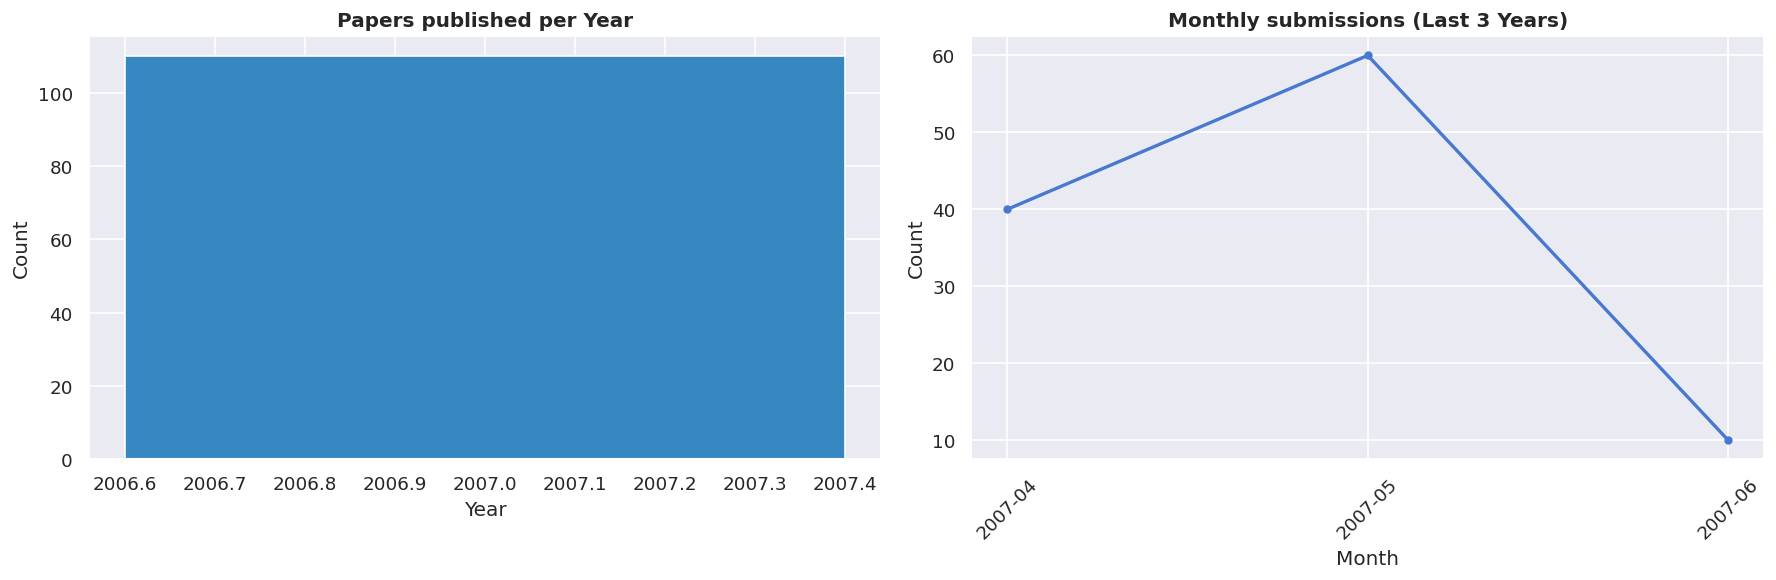

In [4]:
print("\n"+"="*60)
print("PUBLICATION OVER TIME")
print("="*60)

df["year"] = df["date"].dt.year
df["year_month"] = df["date"].dt.to_period("M")

yearly = df.groupby("year").size().reset_index(name = "count")
print("Papers per year:")
print(yearly.to_string(index = False))

fig,axes = plt.subplots(1,2, figsize=(15,5))
axes[0].bar(yearly["year"],yearly["count"], color = sns.color_palette("Blues_d", len(yearly)))
axes[0].set_title("Papers published per Year", fontweight = 'bold')
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f"{int(x):,}"))

recent_cutoff = df["date"].max() - pd.DateOffset(years=3)
monthly = (df[df["date"] >= recent_cutoff].groupby("year_month").size().reset_index(name="count"))
monthly["year_month_str"] = monthly["year_month"].astype(str)

axes[1].plot(monthly["year_month_str"], monthly["count"], marker="o", linewidth=2, markersize=4)
axes[1].set_title("Monthly submissions (Last 3 Years)", fontweight = 'bold')
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)
step = max(1, len(monthly) // 12)
axes[1].set_xticks(axes[1].get_xticks()[::step])

plt.tight_layout()
plt.savefig("eda_publication_volume.png", bbox_inches="tight")
plt.show()


Abstract Length Distribution
Abstract Character Length:
count     110.0
mean      864.6
std       330.2
min       226.0
25%       637.0
50%       821.0
75%      1027.2
max      1751.0
Abstract word count:
count    110.0
mean     130.1
std       51.4
min       32.0
25%       93.5
50%      122.0
75%      161.5
max      281.0

Abstracts under 30 words: 0 (likely incomplete)
Abstracts over 500 words: 0 (unusually long)


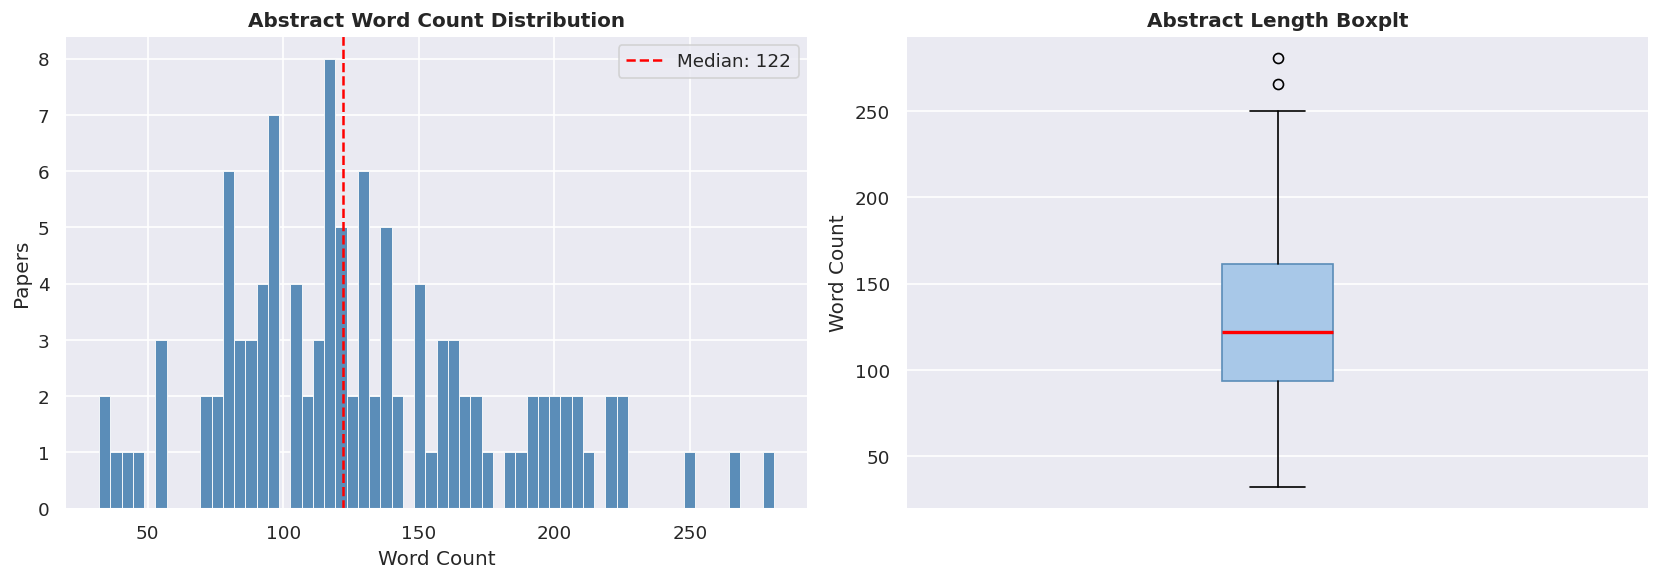

In [5]:
print("\n"+"="*60)
print("Abstract Length Distribution")
print("="*60)

df["abstract_len"] = df["abstract"].str.len()
df["abstract_words"] = df["abstract"].str.split().str.len()

print("Abstract Character Length:")
print(df["abstract_len"].describe().round(1).to_string())
print("Abstract word count:")
print(df["abstract_words"].describe().round(1).to_string())

too_short = df[df["abstract_words"]<30]
too_long = df[df["abstract_words"]>500]
print(f"\nAbstracts under 30 words: {len(too_short)} (likely incomplete)")
print(f"Abstracts over 500 words: {len(too_long)} (unusually long)")

fig,axes = plt.subplots(1,2, figsize=(14,5))

axes[0].hist(df["abstract_words"].clip(upper=600), bins=60, color = "#5B8DB8", edgecolor="white", linewidth=0.5)
axes[0].axvline(df["abstract_words"].median(), color = "red", linestyle = "--", label=f'Median: {df["abstract_words"].median():.0f}')
axes[0].set_title("Abstract Word Count Distribution", fontweight = 'bold')
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Papers")
axes[0].legend()

axes[1].boxplot(df["abstract_words"].clip(upper=600), patch_artist=True, boxprops=dict(facecolor='#A8C8E8', color="#5B8DB8"), medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Abstract Length Boxplt", fontweight="bold")
axes[1].set_ylabel("Word Count")
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig("eda_abstract_length.png", bbox_inches="tight")
plt.show()


Author Activity

Top 20 most prolific authors:
                                authors  paper_count
                      Tshilidzi Marwala            9
                               Matisse)            3
                 T. Kosel and I. Grabec            2
                         Maxim Raginsky            2
                        Larry Wasserman            2
                              H. Satori            2
               M. Harti and N. Chenfour            2
Tshilidzi Marwala and Bodie Crossingham            2
                   Mike Tian-Jian Jiang            2
                           Wen-Lien Hsu            2
         Marc Schoenauer (INRIA Futurs)            2
                      Edgar H. de Graaf            2
                           Joost N. Kok            2
                      Walter A. Kosters            2
                    INRIA Rocquencourt)            2
                             T. Marwala            2
                            D. A. Sofge            

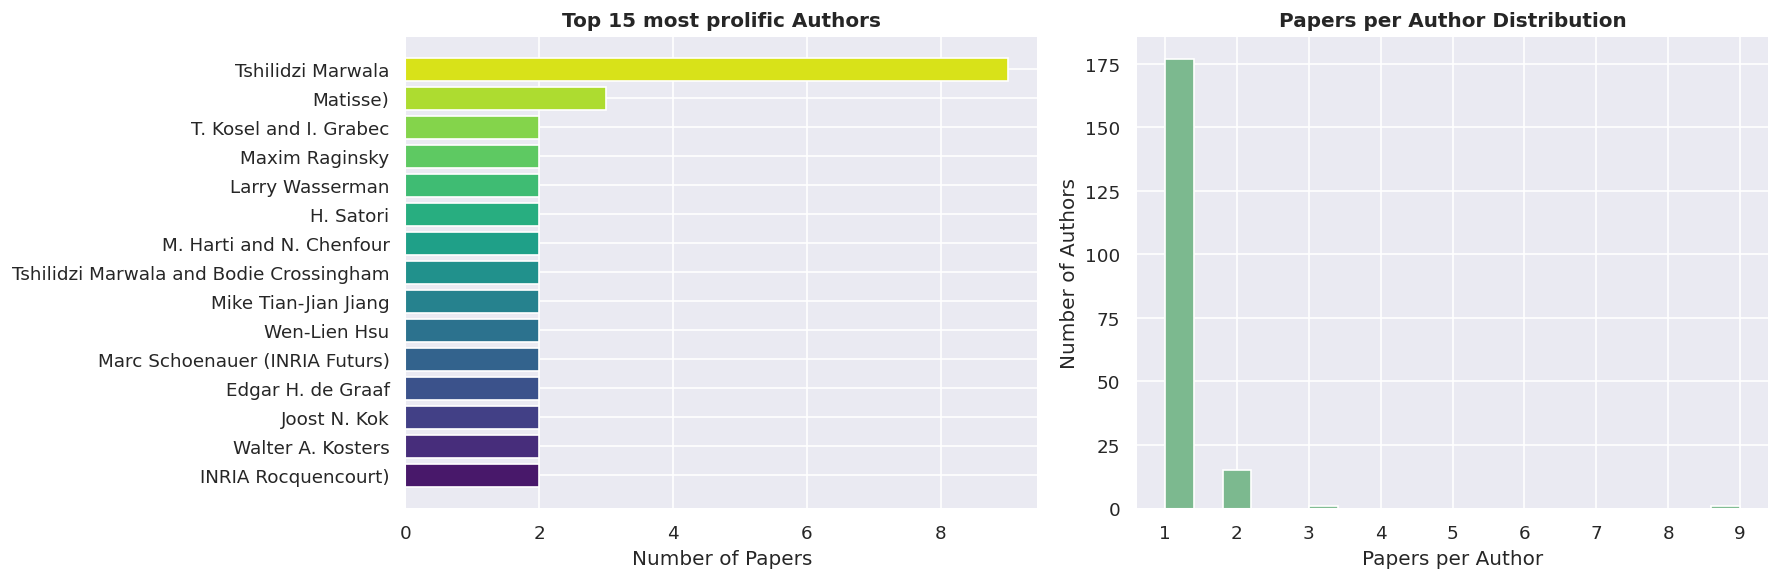

In [6]:
print("\n"+"="*60)
print("Author Activity")
print("="*60)

author_counts = Counter(df["authors"].explode().to_list())
author_df = pd.DataFrame(author_counts.most_common(20), columns=["authors", "paper_count"])

print("\nTop 20 most prolific authors:")
print(author_df.to_string(index=False))

papers_per_author = pd.Series(author_counts.values())
print(f"\nAuthors with 1 paper: {(papers_per_author == 1).sum():,}")
print(f"\nAuthors with 2-5 papers: {papers_per_author.between(2,5).sum():,}")
print(f"\nAuthors with 6+ papers: {(papers_per_author > 6).sum():,}")

fig,axes = plt.subplots(1,2, figsize=(15,5))
axes[0].barh(author_df["authors"][:15][::-1],author_df["paper_count"][:15][::-1], color=sns.color_palette("viridis", 15))
axes[0].set_title("Top 15 most prolific Authors", fontweight = 'bold')
axes[0].set_xlabel("Number of Papers")

axes[1].hist(papers_per_author.clip(upper=20), bins=20, color = "#7CB98F", edgecolor="white")
axes[1].set_title("Papers per Author Distribution", fontweight = 'bold')
axes[1].set_xlabel("Papers per Author")
axes[1].set_ylabel("Number of Authors")

plt.tight_layout()
plt.savefig("eda_author_activity.png", bbox_inches="tight")
plt.show()


Multi-Category Analysis

Categories per paper:
category_count
1    40
2    47
3    17
4     2
5     2
6     2

Top Categories appearing in multi-label papers:
categories
cs.AI      38
cs.NE      21
cs.LG      13
cs.CV       9
cs.CL       8
cs.IT       7
math.IT     7
stat.TH     6
stat.ML     6
math.ST     6


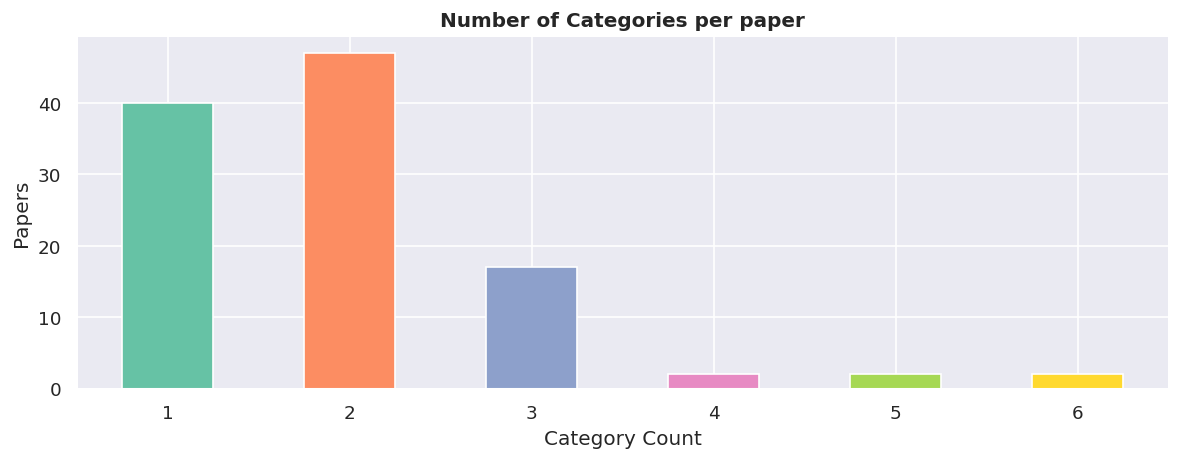

In [7]:
print("\n"+"="*60)
print("Multi-Category Analysis")
print("="*60)

df["category_count"] = df["categories"].apply(len)

print("\nCategories per paper:")
print(df["category_count"].value_counts().sort_index().to_string())

cross = (df[df["category_count"]>1]["categories"].explode().value_counts().head(10))
print("\nTop Categories appearing in multi-label papers:")
print(cross.to_string())

fig, ax = plt.subplots(figsize=(10,4))
df["category_count"].value_counts().sort_index().plot( kind='bar', ax=ax, color=sns.color_palette("Set2", 8))
ax.set_title("Number of Categories per paper", fontweight="bold")
ax.set_xlabel("Category Count")
ax.set_ylabel("Papers")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("eda_multi_category.png", bbox_inches="tight")
plt.show()

In [8]:
print("\n"+"="*60)
print("Data Quality Flags")
print("="*60)

df["flag_short_abstract"] = df["abstract_words"] < 30
df["flag_no_date"] = df["date"].isna()
df["flag_no_authors"] = df["authors"].apply(lambda x: len(x) == 0)
df["flag_duplicate_title"] = df.duplicated(subset=["title"], keep=False)

quality = {
    "Short abstract (<30 words)" : df["flag_short_abstract"].sum(),
    "Mising Date"                : df["flag_no_date"].sum(),
    "Missing Authors"            : df["flag_no_authors"].sum(),
    "Duplicate Titles"           : df["flag_duplicate_title"].sum(),
}

for flag, count in quality.items():
    pct = count/len(df)*100
    print(f"{flag:<35}: {count:>5} ({pct:.2f}%)")


Data Quality Flags
Short abstract (<30 words)         :     0 (0.00%)
Mising Date                        :     0 (0.00%)
Missing Authors                    :     0 (0.00%)
Duplicate Titles                   :     0 (0.00%)


In [9]:
print("\n"+"="*60)
print("Saving Filtered Dataset")
print("="*60)

df_filtered = df[
   (~df["flag_short_abstract"])&
   (~df["flag_no_date"])&
   (~df["flag_no_authors"])&
   (~df["flag_duplicate_title"])
].copy()

DROP_COLS = [
    "flag_short_abstract","flag_no_date","flag_no_authors",
    "flag_duplicate_title","abstract_len","abstract_words",
    "year","year_month","category_count"
]
df_filtered.drop(columns = DROP_COLS, inplace=True)
print(f"\nBefor filtering: {len(df):,} papers")
print(f"After filtering: {len(df_filtered):,} papers")
print(f"Removed        : {len(df) - len(df_filtered):,}   papers")

df_filtered.to_parquet("arxiv_ml_filtered.parquet", index=False)
print("\nSaved: arxiv_ml_filtered.parquet")

df_filtered.to_csv("arxiv_ml_filtered.csv", index=False)
print("Saved: arxiv_ml_filtered.csv")


Saving Filtered Dataset

Befor filtering: 110 papers
After filtering: 110 papers
Removed        : 0   papers

Saved: arxiv_ml_filtered.parquet
Saved: arxiv_ml_filtered.csv


In [10]:
verify = pd.read_parquet("arxiv_ml_filtered.parquet")
assert verify.shape == df_filtered.shape, "Shape mismatch after save"
print(f"\nVerification passed -- shape: {verify.shape}")
print("\nFinal Column List:")
for col in verify.columns:
    print(f"{col:<20}{verify[col].dtype}")


Verification passed -- shape: (110, 8)

Final Column List:
paper_id            object
title               object
abstract            object
authors             object
categories          object
date                datetime64[ns]
journal_ref         object
doi                 object
